In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor


df = pd.read_csv('vietnam_housing_dataset.csv')
display(df.head())



,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


In [9]:
for col in ['Frontage', 'Access Road', 'Bedrooms', 'Bathrooms', 'Floors']:
    df[col] = df[col].fillna(df[col].median())

for col in ['House direction', 'Balcony direction', 'Legal status', 'Furniture state']:
    df[col] = df[col].fillna(df[col].mode()[0])


df = df[(df['Area'] > 10) & (df['Area'] < 1000)]
df = df[(df['Price'] > 0) & (df['Price'] < 200)]

df_model = df.drop(columns=['Address'])

label_encoders = {}
cat_cols = ['House direction', 'Balcony direction', 'Legal status', 'Furniture state']
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

display(df_model.info())



<class 'pandas.DataFrame'>
Index: 30210 entries, 0 to 30228
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               30210 non-null  float64
 1   Frontage           30210 non-null  float64
 2   Access Road        30210 non-null  float64
 3   House direction    30210 non-null  int64  
 4   Balcony direction  30210 non-null  int64  
 5   Floors             30210 non-null  float64
 6   Bedrooms           30210 non-null  float64
 7   Bathrooms          30210 non-null  float64
 8   Legal status       30210 non-null  int64  
 9   Furniture state    30210 non-null  int64  
 10  Price              30210 non-null  float64
dtypes: float64(7), int64(4)
memory usage: 2.8 MB


None

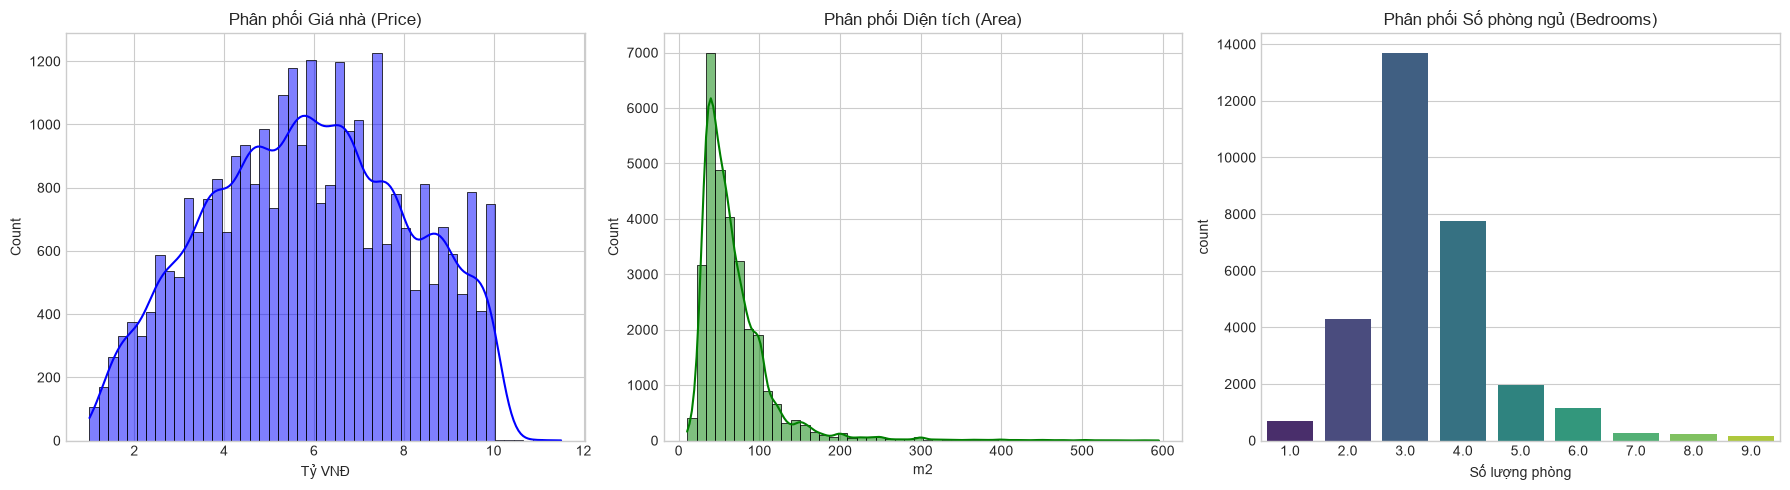

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Price'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Phân phối Giá nhà (Price)')
axes[0].set_xlabel('Tỷ VNĐ')

sns.histplot(df['Area'], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Phân phối Diện tích (Area)')
axes[1].set_xlabel('m2')

sns.countplot(data=df, x='Bedrooms', ax=axes[2], palette='viridis')
axes[2].set_title('Phân phối Số phòng ngủ (Bedrooms)')
axes[2].set_xlabel('Số lượng phòng')

plt.tight_layout()
plt.show()



In [14]:
X = df_model.drop(columns=['Price'])
y = df_model['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2,
        "MAPE": mape
    })

df_results = pd.DataFrame(results)
display(df_results.sort_values(by="R2 Score", ascending=False))



,Model,MAE,MSE,RMSE,R2 Score,MAPE
4,XGBoost,1.413557,3.209346,1.791465,0.342229,0.317017
3,Gradient Boosting,1.452095,3.266681,1.807396,0.330478,0.332220
2,Random Forest,1.440407,3.436733,1.853843,0.295625,0.321786
0,Linear Regression,1.604545,3.879058,1.969532,0.204969,0.370707
1,Decision Tree,1.774777,5.565806,2.359196,-0.140738,0.386215


# Lý do lựa chọn mô hình XGBoost

Dựa vào bảng kết quả đánh giá ở trên, **XGBoost** được lựa chọn làm mô hình cuối cùng để triển khai vì các lý do sau:

1. **Hiệu suất tốt nhất:** XGBoost đạt chỉ số **R² Score cao nhất**, chứng tỏ nó giải thích được tốt nhất sự biến thiên của giá nhà dựa trên các biến đầu vào. Đồng thời, các chỉ số sai số như **MAE, RMSE và MAPE đều thấp nhất** so với Linear Regression, Decision Tree hay Random Forest.
2. **Khả năng bắt dữ liệu phức tạp:** Giá nhà ở Việt Nam phụ thuộc rất phức tạp vào diện tích, số phòng và mặt tiền. Thuật toán boosting của XGBoost cực kỳ xuất sắc trong việc học các mối quan hệ phi tuyến tính này.
3. **Tốc độ và Tối ưu hóa:** Khác với Gradient Boosting thông thường, XGBoost có các kỹ thuật chuẩn hóa tích hợp bên trong giúp chống lại hiện tượng học vẹt rất hiệu quả, đồng thời tối ưu hóa bộ nhớ và tốc độ huấn luyện. 


In [12]:
best_model = models["XGBoost"]

filename = 'house_price_model.sav'
pickle.dump(best_model, open(filename, 'wb'))
print(f"Đã lưu mô hình tốt nhất vào file {filename} để chuẩn bị triển khai lên Mobile!")



Đã lưu mô hình tốt nhất vào file house_price_model.sav để chuẩn bị triển khai lên Mobile!
